In [4]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

from brainspace.utils.parcellation import map_to_labels, reduce_by_labels
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import pingouin

bids_folder_numrisk = '/mnt_04/ds-numrisk' 
bids_folder_dnumrisk = '/mnt_03/ds-dnumrisk'

In [5]:
from utils_02 import get_behave_bauer_params

df_behave_dyscalc = get_behave_bauer_params(bids_folder=bids_folder_dnumrisk, dataset='dyscalc',unbiased=True)
df_behave_mig = get_behave_bauer_params(bids_folder=bids_folder_numrisk, dataset='miguel',unbiased=True)

df_behave = pd.concat([df_behave_mig, df_behave_dyscalc])
df_behave = df_behave.drop(columns='group')
df_behave

,,perceptual_noise_sd,memory_noise_sd
subject,dataset,,
1,miguel,0.119338,0.164649
2,miguel,0.144083,0.141128
3,miguel,0.159790,0.204653
4,miguel,0.165733,0.240002
5,miguel,0.145187,0.252977
...,...,...,...
62,dyscalc,0.067225,0.102723
63,dyscalc,0.167108,0.081719
64,dyscalc,0.113884,0.113829


In [29]:
n_grad = 2
phenotype_folder = op.join(bids_folder_dnumrisk, 'derivatives','phenotype')
df_neuro_dyscalc = pd.read_csv(op.join(phenotype_folder,f'betweenNdispersion_grad-{n_grad}.csv'))
df_neuro_dyscalc['dataset'] = 'dyscalc'
df_neuro_dyscalc.set_index(['subject','dataset'], inplace=True)

phenotype_folder = op.join(bids_folder_numrisk, 'derivatives','phenotype')
df_neuro_miguel = pd.read_csv(op.join(phenotype_folder,f'betweenNdispersion_grad-{n_grad}.csv'))
df_neuro_miguel['dataset'] = 'miguel'
df_neuro_miguel.set_index(['subject','dataset'], inplace=True)

df_neuro= pd.concat([df_neuro_miguel, df_neuro_dyscalc])#drop(columns='group', inplace=True)
df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'
df_neuro.loc[df_neuro['group'] == 0, 'group'] = 'control_dyscalc'
df_neuro.loc[df_neuro['group'] == 1, 'group'] = 'dyscalc'

/tmp/ipykernel_1689171/1578271312.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'control_miguel' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_neuro.loc[pd.isna(df_neuro['group']), 'group'] = 'control_miguel'


In [7]:
#df_neuro.drop(columns='group', inplace=True)
df_comb = df_neuro.join(df_behave)
df_comb

,,Visual1 - Visual2,Visual1 - Somatomotor,Visual1 - Cingulo-Opercular,Visual1 - Dorsal-attention,Visual1 - Language,Visual1 - Frontoparietal,Visual1 - Auditory,Visual1 - Default,Visual1 - Posterior-Multimodal,Visual1 - Ventral-Multimodal,...,Auditory - Orbito-Affective,Default - Posterior-Multimodal,Default - Ventral-Multimodal,Default - Orbito-Affective,Posterior-Multimodal - Ventral-Multimodal,Posterior-Multimodal - Orbito-Affective,Ventral-Multimodal - Orbito-Affective,group,perceptual_noise_sd,memory_noise_sd
subject,dataset,,,,,,,,,,,,,,,,,,,,,
40,miguel,0.824491,5.717017,5.565062,4.949173,6.051603,7.092668,5.174740,10.036589,6.999900,10.263666,...,6.200165,3.036689,0.227077,1.338316,3.263766,4.375005,1.111239,control_miguel,0.150022,0.172125
62,miguel,0.438268,5.686233,5.175991,4.548746,8.618781,7.850056,4.246157,12.286133,6.115499,13.996872,...,5.138651,6.170634,1.710739,2.901326,7.881373,3.269309,4.612065,control_miguel,0.190866,0.163272
41,miguel,1.129387,5.120319,5.210502,4.136427,6.862173,8.420695,4.897230,11.982744,4.566525,11.879968,...,5.335547,7.416219,0.102775,1.749967,7.313444,5.666252,1.647192,control_miguel,0.127207,0.204029
31,miguel,0.632881,2.954648,5.299223,4.124287,5.777394,8.798611,2.615659,11.736730,4.851866,9.301575,...,7.497297,6.884864,2.435155,1.623774,4.449709,5.261090,0.811381,control_miguel,0.114351,0.141577
64,miguel,0.370076,6.007723,5.850609,5.432709,7.814889,9.677059,5.927451,12.491884,5.068541,9.528623,...,4.108805,7.423343,2.963261,2.455628,4.460082,4.967715,0.507633,control_miguel,0.149707,0.203329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,dyscalc,1.174162,5.934475,5.889509,5.031793,6.334130,6.334158,5.033586,8.064574,4.858705,13.437558,...,5.304284,3.205869,5.372984,2.273296,8.578853,5.479165,3.099688,control_dyscalc,0.083263,0.092911
42,dyscalc,0.567047,5.334191,5.488658,4.976922,7.835069,10.327399,4.809582,14.197156,5.592925,9.868599,...,6.255169,8.604231,4.328557,3.132406,4.275674,5.471825,1.196151,dyscalc,0.077095,0.109045
25,dyscalc,0.659571,5.324372,5.046377,4.797456,6.389516,7.089790,4.314860,9.287916,3.158785,11.539995,...,5.169299,6.129130,2.252080,0.196243,8.381210,6.325373,2.055837,dyscalc,0.162504,0.125818


In [9]:
df_neuro.set_index('group',append=True)

,,,Visual1 - Visual2,Visual1 - Somatomotor,Visual1 - Cingulo-Opercular,Visual1 - Dorsal-attention,Visual1 - Language,Visual1 - Frontoparietal,Visual1 - Auditory,Visual1 - Default,Visual1 - Posterior-Multimodal,Visual1 - Ventral-Multimodal,...,Auditory - Default,Auditory - Posterior-Multimodal,Auditory - Ventral-Multimodal,Auditory - Orbito-Affective,Default - Posterior-Multimodal,Default - Ventral-Multimodal,Default - Orbito-Affective,Posterior-Multimodal - Ventral-Multimodal,Posterior-Multimodal - Orbito-Affective,Ventral-Multimodal - Orbito-Affective
subject,dataset,group,,,,,,,,,,,,,,,,,,,,,
40,miguel,control_miguel,0.824491,5.717017,5.565062,4.949173,6.051603,7.092668,5.174740,10.036589,6.999900,10.263666,...,4.861849,1.825160,5.088926,6.200165,3.036689,0.227077,1.338316,3.263766,4.375005,1.111239
62,miguel,control_miguel,0.438268,5.686233,5.175991,4.548746,8.618781,7.850056,4.246157,12.286133,6.115499,13.996872,...,8.039977,1.869342,9.750715,5.138651,6.170634,1.710739,2.901326,7.881373,3.269309,4.612065
41,miguel,control_miguel,1.129387,5.120319,5.210502,4.136427,6.862173,8.420695,4.897230,11.982744,4.566525,11.879968,...,7.085514,0.330705,6.982739,5.335547,7.416219,0.102775,1.749967,7.313444,5.666252,1.647192
31,miguel,control_miguel,0.632881,2.954648,5.299223,4.124287,5.777394,8.798611,2.615659,11.736730,4.851866,9.301575,...,9.121071,2.236208,6.685917,7.497297,6.884864,2.435155,1.623774,4.449709,5.261090,0.811381
64,miguel,control_miguel,0.370076,6.007723,5.850609,5.432709,7.814889,9.677059,5.927451,12.491884,5.068541,9.528623,...,6.564433,0.858910,3.601172,4.108805,7.423343,2.963261,2.455628,4.460082,4.967715,0.507633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,dyscalc,control_dyscalc,1.174162,5.934475,5.889509,5.031793,6.334130,6.334158,5.033586,8.064574,4.858705,13.437558,...,3.030988,0.174881,8.403972,5.304284,3.205869,5.372984,2.273296,8.578853,5.479165,3.099688
42,dyscalc,dyscalc,0.567047,5.334191,5.488658,4.976922,7.835069,10.327399,4.809582,14.197156,5.592925,9.868599,...,9.387574,0.783343,5.059017,6.255169,8.604231,4.328557,3.132406,4.275674,5.471825,1.196151
25,dyscalc,dyscalc,0.659571,5.324372,5.046377,4.797456,6.389516,7.089790,4.314860,9.287916,3.158785,11.539995,...,4.973056,1.156075,7.225136,5.169299,6.129130,2.252080,0.196243,8.381210,6.325373,2.055837


In [14]:
from utils import get_glasser_parcels, get_glasser_CAatlas_mapping

glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()


In [22]:
        tmp = df_neuro[net_name_comp].to_frame().join(df_behave)


pandas.core.frame.DataFrame

In [34]:
N_nets = 12

y_var = 'memory_noise_sd'

mat_pvals = np.ones([N_nets, N_nets])
mat_rs = np.zeros([N_nets, N_nets])

for n1 in range(1,N_nets+1):
    for n2 in range(n1+1, N_nets+1):
        net_name_comp = str(CAatlas_names.loc[n1]['Network Name']) +  ' - ' + str(CAatlas_names.loc[n2]['Network Name'])
        #print(net_name_comp)
        x_var = net_name_comp
        
        cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'spearman') #defautl: two -sided & pearson 
        mat_rs[n1-1,n2-1] = np.round(cor['r'].iloc[0], 2)
        mat_pvals[n1-1,n2-1] = np.round(cor['p-val'].iloc[0], 3)


Text(0.5, 1.1, 'Correlation Coefficients of memory_noise_sd with between network distance \n Grad 2, group-all')

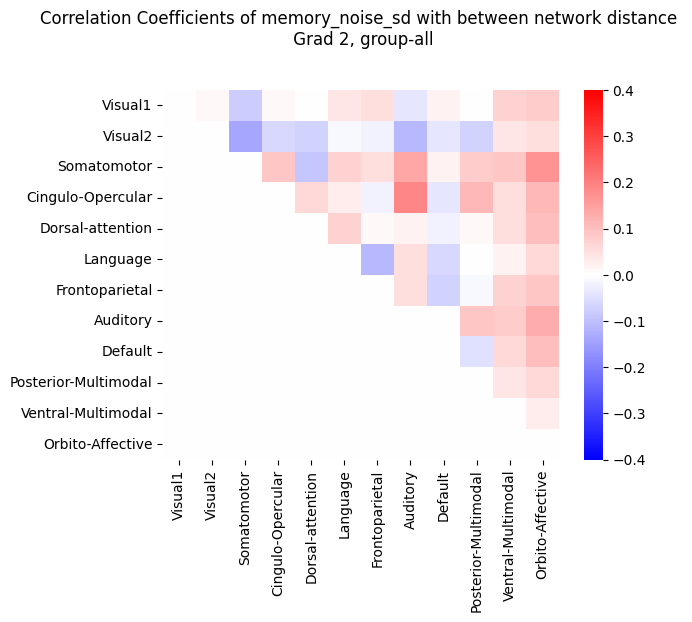

In [35]:
group = 'all'
sns.heatmap(mat_rs, cmap='bwr',vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Correlation Coefficients of {y_var} with between network distance \n Grad {n_grad}, group-{group}', y=1.1)

/tmp/ipykernel_2328493/3827972565.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2328493/3827972565.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 5)


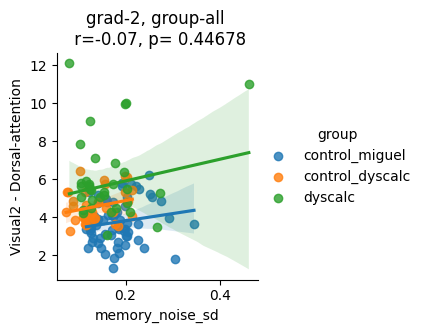

In [9]:
x_var = 'memory_noise_sd' #'perceptual_noise_sd' # 'Percent Correct'# _unbiased 'memory_noise_sd_unbiased
y_var = 'Visual2 - Dorsal-attention'
n_grad = 2

group = 'all'#['control_dyscalc','dyscalc' ] #'all' # 'control_miguel'

import pingouin
tmp = tmp = df_comb[df_comb['group'].isin(group)] if group != 'all' else df_comb #.drop(46, level='subject') # sub-46 drives effect !
cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'spearman') # shepherd,spearman,pearson || defautl: two -sided & pearson 
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)

fig = sns.lmplot(x=x_var, y=y_var, data=tmp,height=3, robust=True, hue='group') #  hue='group',
fig.set(title=f'grad-{n_grad}, group-{group} \n r={r_}, p= {p}' ) 

# pearson got effect but only when sub-46 is included --> not robust to outliers

<Axes: xlabel='Visual2 - Dorsal-attention', ylabel='Density'>

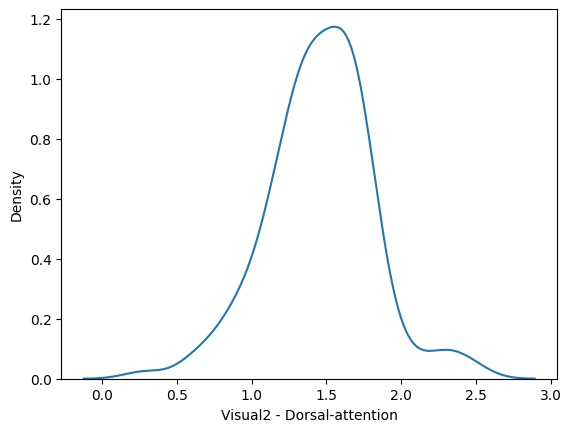

In [12]:
sns.kdeplot(np.log(tmp[y_var]))

## prelim results:

without dyscalc-group-biased effect for memory_noise no correlation survives 

In [19]:
df_comb['group'] = df_comb['group'].map({'control_dyscalc':'control', 'dyscalc':'dyscalc', 'control_miguel':'control'})

In [20]:
x_var = 'memory_noise_sd' #'perceptual_noise_sd' # 'Percent Correct'# _unbiased 'memory_noise_sd_unbiased
y_var = 'Visual2 - Dorsal-attention'

formula = 'neuralVar ~ behaveVar + group + dataset'
formula = 'behaveVar ~ neuralVar + group + dataset'

import statsmodels.api as sm

df_comb['neuralVar'] = np.log(df_comb[y_var])
df_comb['behaveVar'] = np.log(df_comb[x_var])

result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

In [21]:
formula = 'neuralVar ~ behaveVar + group + dataset'
result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              neuralVar   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     19.57
Date:                Mon, 06 Jan 2025   Prob (F-statistic):           1.83e-10
Time:                        08:53:36   Log-Likelihood:                -23.085
No. Observations:                 129   AIC:                             54.17
Df Residuals:                     125   BIC:                             65.61
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.6960      0.187      9.082      0.000       1.326       2.066
group[T.dyscalc]      0.2241      0.074      3.040      0.003       0.078       0.370
dataset[T.miguel]    -0.2634      0.069     -3.820      0.000      -0.400      -0.127
behaveVar             0.0912      0.088      1.038      0.301      -0.083       0.265
==============================================================================
Omnibus:                        3.243   Durbin-Watson:                   2.149
Prob(Omnibus):                  0.198   Jarque-Bera (JB):                2.933
Skew:                          -0.208   Prob(JB):                        0.231
Kurtosis:                       3.611   Cond. No.                         17.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
formula = 'behaveVar ~ neuralVar + group + dataset'
result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              behaveVar   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     8.583
Date:                Mon, 06 Jan 2025   Prob (F-statistic):           3.17e-05
Time:                        08:53:55   Log-Likelihood:                -24.725
No. Observations:                 129   AIC:                             57.45
Df Residuals:                     125   BIC:                             68.89
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.1835      0.146    -14.986      0.000      -2.472      -1.895
group[T.dyscalc]      0.1369      0.076      1.792      0.076      -0.014       0.288
dataset[T.miguel]     0.3358      0.067      4.983      0.000       0.202       0.469
neuralVar             0.0936      0.090      1.038      0.301      -0.085       0.272
==============================================================================
Omnibus:                        4.685   Durbin-Watson:                   1.896
Prob(Omnibus):                  0.096   Jarque-Bera (JB):                4.123
Skew:                           0.400   Prob(JB):                        0.127
Kurtosis:                       3.357   Cond. No.                         12.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""